In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración de visualización
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Ignorar warnings
warnings.filterwarnings('ignore')

## Carga del Dataset y exploracion de variables

In [75]:
df = pd.read_csv('../data/dataset.csv')

In [76]:
# Informacion basica del dataset
print('Informacion del dataset:')
print("="*50)
print(f"Forma del dataset: {df.shape}")
print(f"Columnas del dataset: \n{df.columns}")
# print(df.head())
print(f"Valores nulos: \n{df.isnull().sum()}")


Informacion del dataset:
Forma del dataset: (1338, 7)
Columnas del dataset: 
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
Valores nulos: 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [77]:
print("\nSummary de info del archivo\n")
print (df.info())



Summary de info del archivo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [78]:
df.duplicated().sum()
df[df.duplicated(keep=False)]
df=df.drop_duplicates()
df.shape[0]

1337

#### Variables numéricas

In [ ]:
# Descripcion de variables numericas
print (df.describe())

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


#### Variables categóricas

In [80]:
# Estadísticas para variables categóricas
print("\nDistribución de variables categóricas:")
for col in ['sex', 'smoker', 'region']:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Proporción:\n{df[col].value_counts(normalize=True)}")


Distribución de variables categóricas:

sex:
sex
male      675
female    662
Name: count, dtype: int64
Proporción:
sex
male      0.504862
female    0.495138
Name: proportion, dtype: float64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64
Proporción:
smoker
no     0.795064
yes    0.204936
Name: proportion, dtype: float64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
Proporción:
region
southeast    0.272251
southwest    0.243082
northwest    0.242334
northeast    0.242334
Name: proportion, dtype: float64


### Visualizaciones y analisis de charges

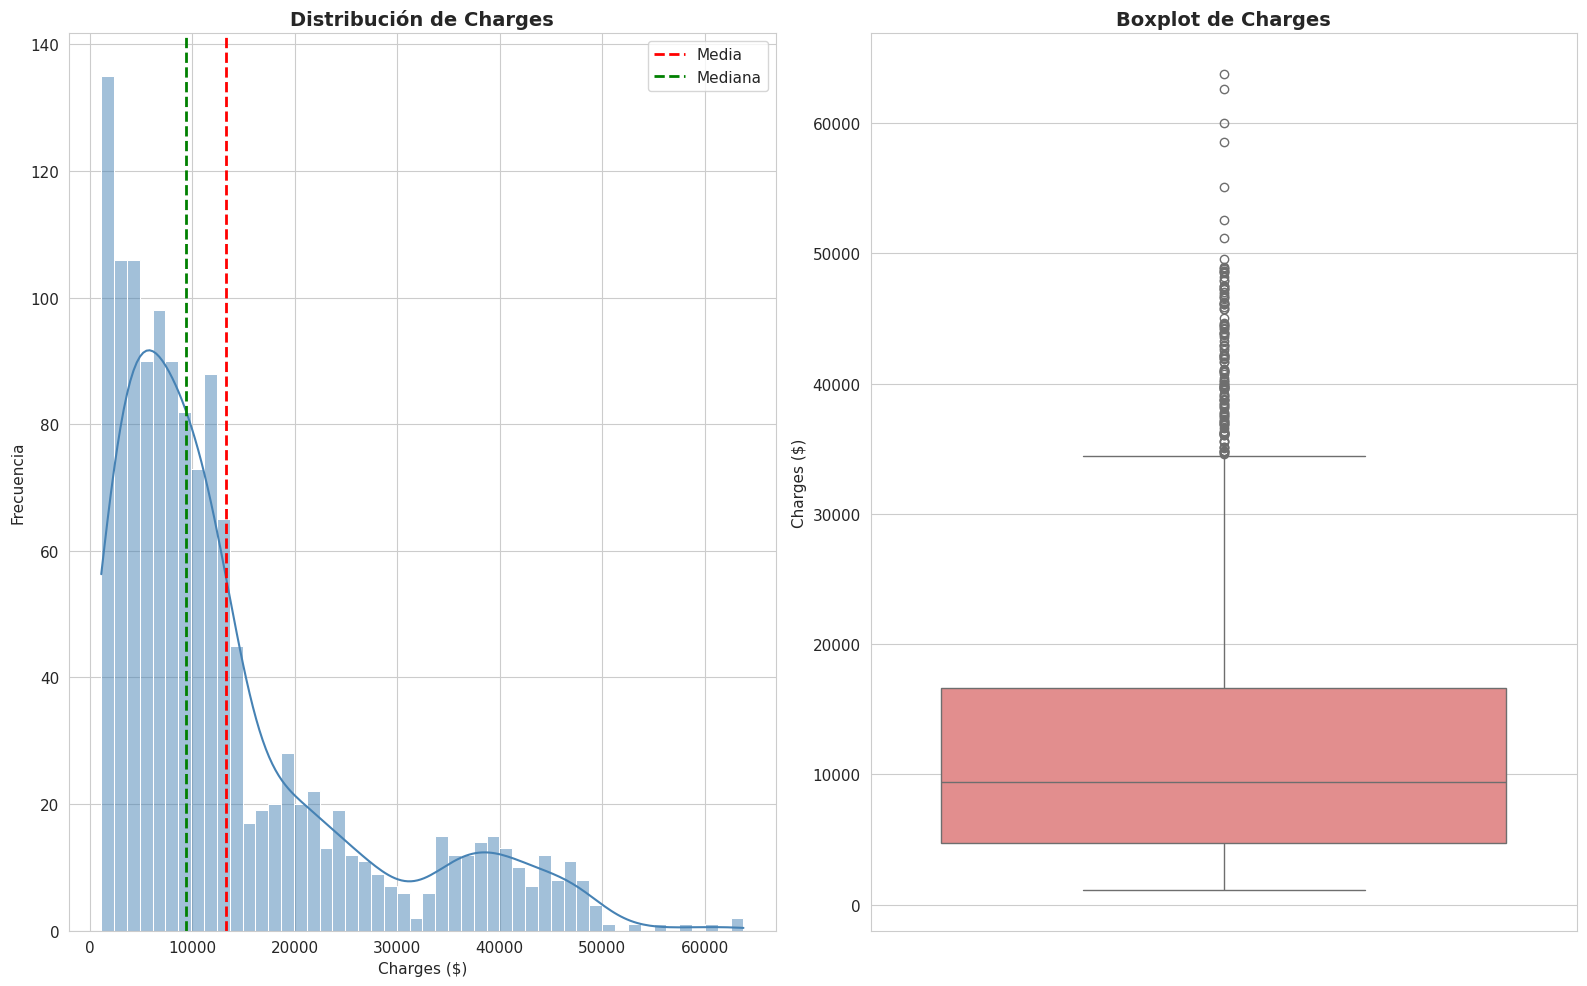

In [89]:
# Visualización completa de charges
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 1. Histograma con KDE
sns.histplot(data=df, x='charges', kde=True, bins=50, ax=axes[0], color='steelblue')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].axvline(df['charges'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].set_title('Distribución de Charges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. Boxplot
sns.boxplot(y=df['charges'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot de Charges', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

In [115]:
print(f"Media:      ${df['charges'].mean():,.2f}")
print(f"Mediana:    ${df['charges'].median():,.2f}")
print(f"Desv. Est.: ${df['charges'].std():,.2f}")
print(f"Mínimo:     ${df['charges'].min():,.2f}")
print(f"Máximo:     ${df['charges'].max():,.2f}")
print(f"Skewness:   {df['charges'].skew():.3f} (distribución asimétrica)")
print(f"Kurtosis:   {df['charges'].kurtosis():.3f} (colas pesadas)")

Media:      $13,279.12
Mediana:    $9,386.16
Desv. Est.: $12,110.36
Mínimo:     $1,121.87
Máximo:     $63,770.43
Skewness:   1.515 (distribución asimétrica)
Kurtosis:   1.604 (colas pesadas)


### Distribucion de variables numericas


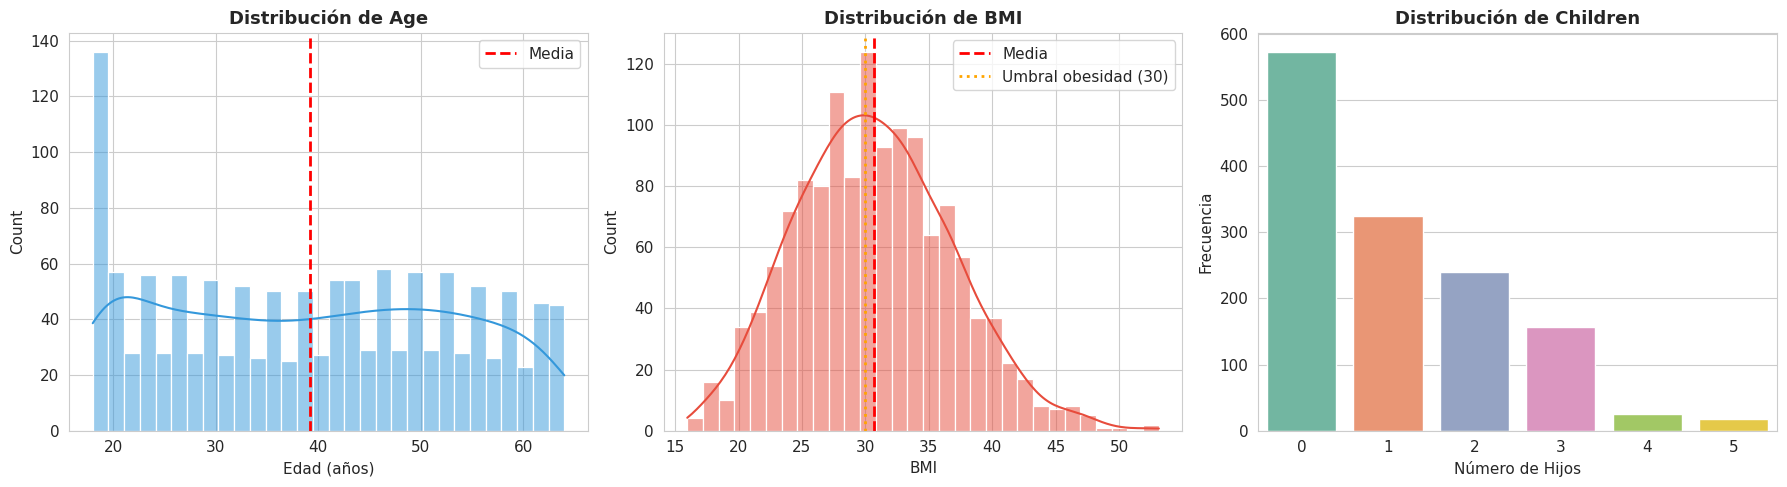

In [90]:
# Distribuciones de variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age
sns.histplot(data=df, x='age', kde=True, bins=30, ax=axes[0], color='#3498db')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].set_title('Distribución de Age', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].legend()

# BMI
sns.histplot(data=df, x='bmi', kde=True, bins=30, ax=axes[1], color='#e74c3c')
axes[1].axvline(df['bmi'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[1].axvline(30, color='orange', linestyle=':', linewidth=2, label='Umbral obesidad (30)')
axes[1].set_title('Distribución de BMI', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].legend()

# Children
sns.countplot(data=df, x='children', ax=axes[2], palette='Set2')
axes[2].set_title('Distribución de Children', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Número de Hijos')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Analisis de correlaciones


               age       sex       bmi  children    smoker   charges
age       1.000000 -0.019814  0.109344  0.041536 -0.025587  0.298308
sex      -0.019814  1.000000  0.046397  0.017848  0.076596  0.058044
bmi       0.109344  0.046397  1.000000  0.012755  0.003746  0.198401
children  0.041536  0.017848  0.012755  1.000000  0.007331  0.067389
smoker   -0.025587  0.076596  0.003746  0.007331  1.000000  0.787234
charges   0.298308  0.058044  0.198401  0.067389  0.787234  1.000000


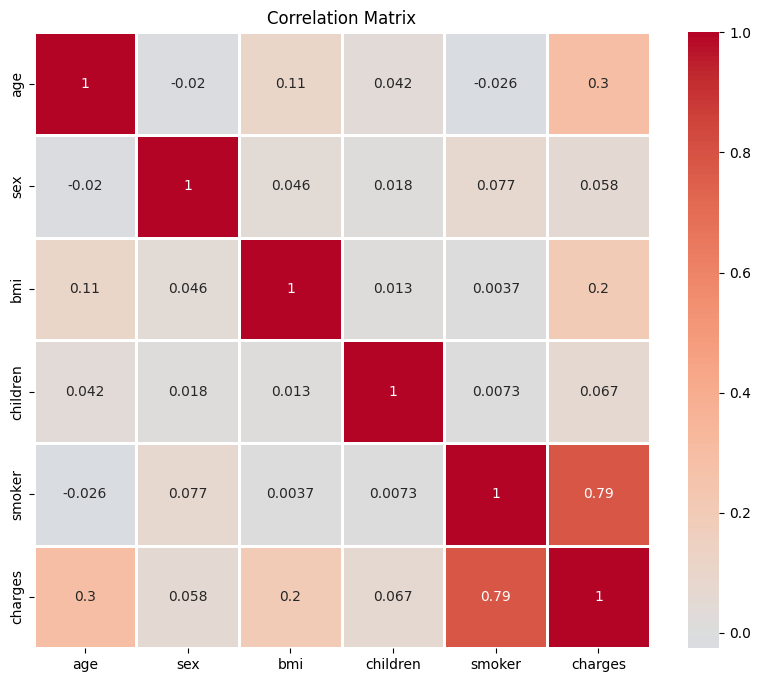


Correlación con charges:
charges     1.000000
smoker      0.787234
age         0.298308
bmi         0.198401
children    0.067389
sex         0.058044
Name: charges, dtype: float64


In [50]:

# Codificar variables categóricas para correlación
df_encoded = df.copy()
df_encoded['sex'] = (df_encoded['sex'] == 'male').astype(int)
df_encoded['smoker'] = (df_encoded['smoker'] == 'yes').astype(int)
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

correlation_matrix = df_encoded[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr()
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.show()

print("\nCorrelación con charges:")
print(correlation_matrix['charges'].sort_values(ascending=False))

### Analisis por grupos

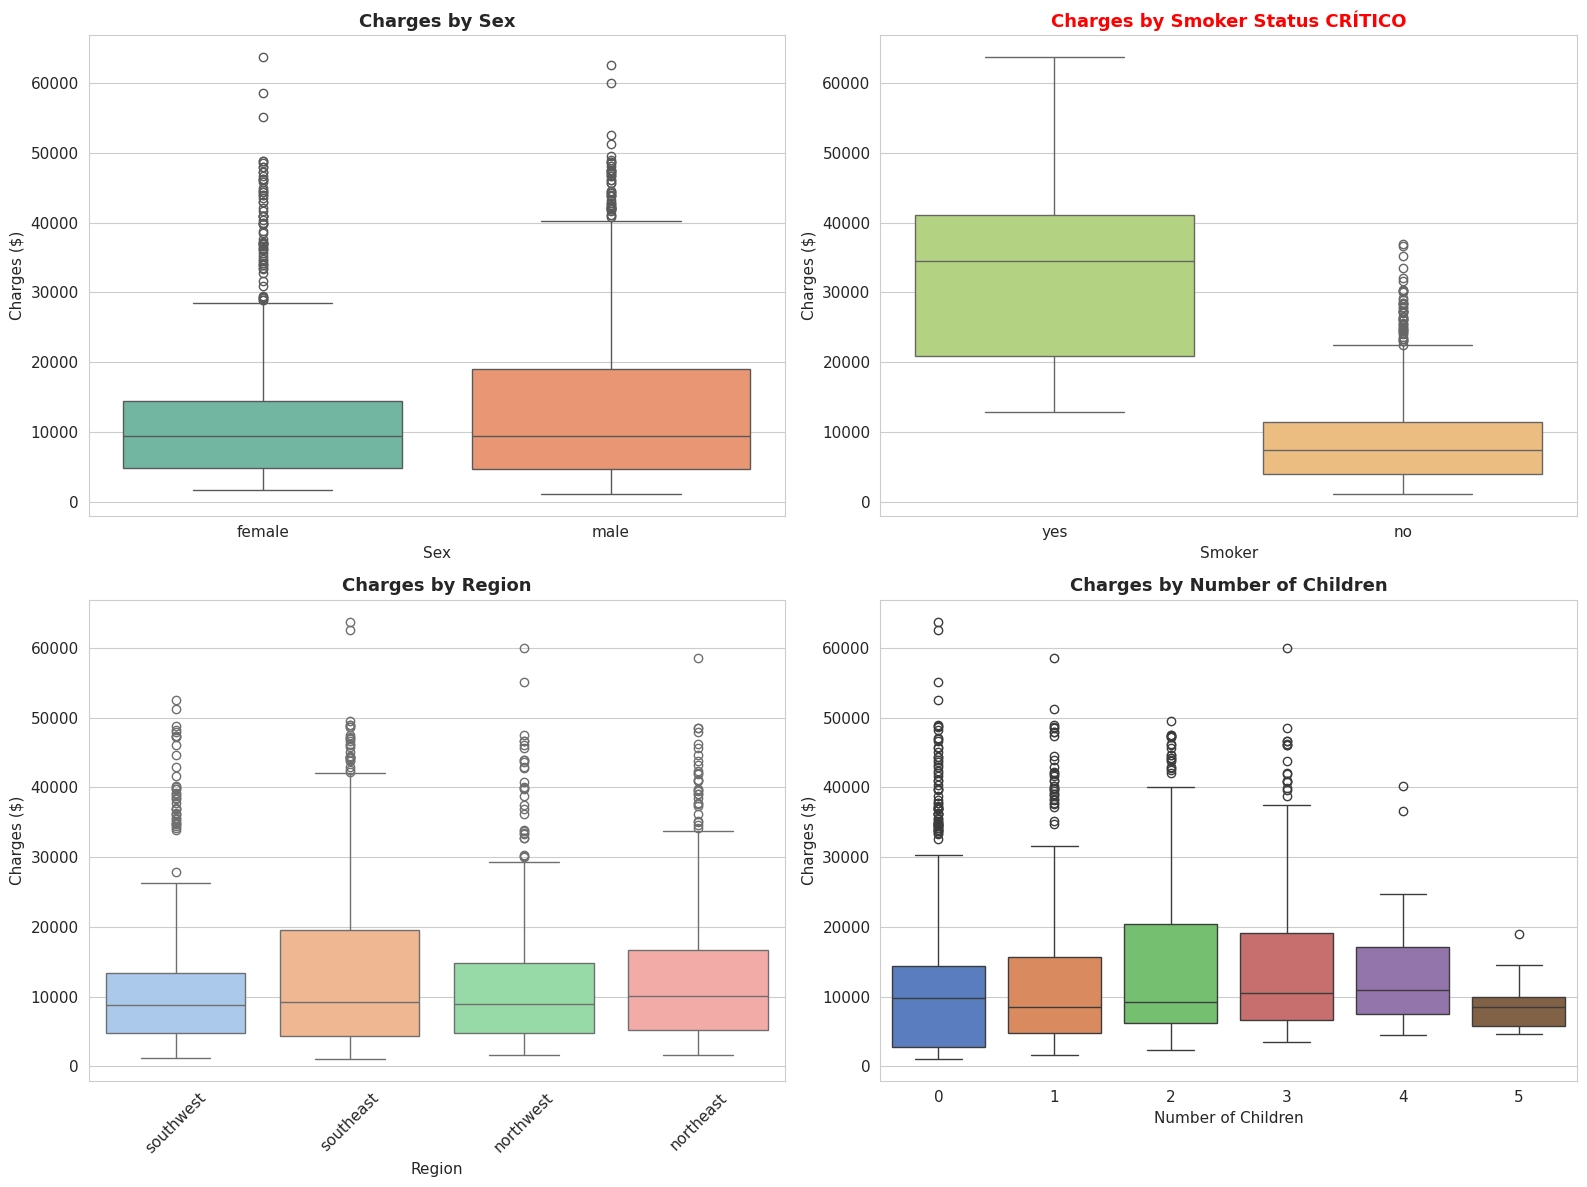

In [92]:
# Análisis de charges por grupos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sex
sns.boxplot(data=df, x='sex', y='charges', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Charges by Sex', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Charges ($)')
axes[0, 0].set_xlabel('Sex')

# 2. Smoker (LA MÁS IMPORTANTE)
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0, 1], palette='RdYlGn_r')
axes[0, 1].set_title('Charges by Smoker Status CRÍTICO', fontsize=13, fontweight='bold', color='red')
axes[0, 1].set_ylabel('Charges ($)')
axes[0, 1].set_xlabel('Smoker')

# 3. Region
sns.boxplot(data=df, x='region', y='charges', ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Charges by Region', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Charges ($)')
axes[1, 0].set_xlabel('Region')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Children
sns.boxplot(data=df, x='children', y='charges', ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('Charges by Number of Children', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Charges ($)')
axes[1, 1].set_xlabel('Number of Children')

plt.tight_layout()
plt.show()

### Analisis de interacciones para Feature Engineering

In [94]:
# Estadísticas por Smoker (factor más importante)
print('='*70)
print('CHARGES POR SMOKER STATUS')
print('='*70)
smoker_stats = df.groupby('smoker')['charges'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(smoker_stats)

# Calcular ratio
ratio = smoker_stats.loc['yes', 'mean'] / smoker_stats.loc['no', 'mean']
print(f"\nLos fumadores tienen costos {ratio:.2f}x mayores que los no fumadores")

CHARGES POR SMOKER STATUS
        count          mean       median           std         min  \
smoker                                                               
no       1063   8440.660307   7345.72660   5992.973800   1121.8739   
yes       274  32050.231832  34456.34845  11541.547176  12829.4551   

                max  
smoker               
no      36910.60803  
yes     63770.42801  

Los fumadores tienen costos 3.80x mayores que los no fumadores


#### BMI x Smoker

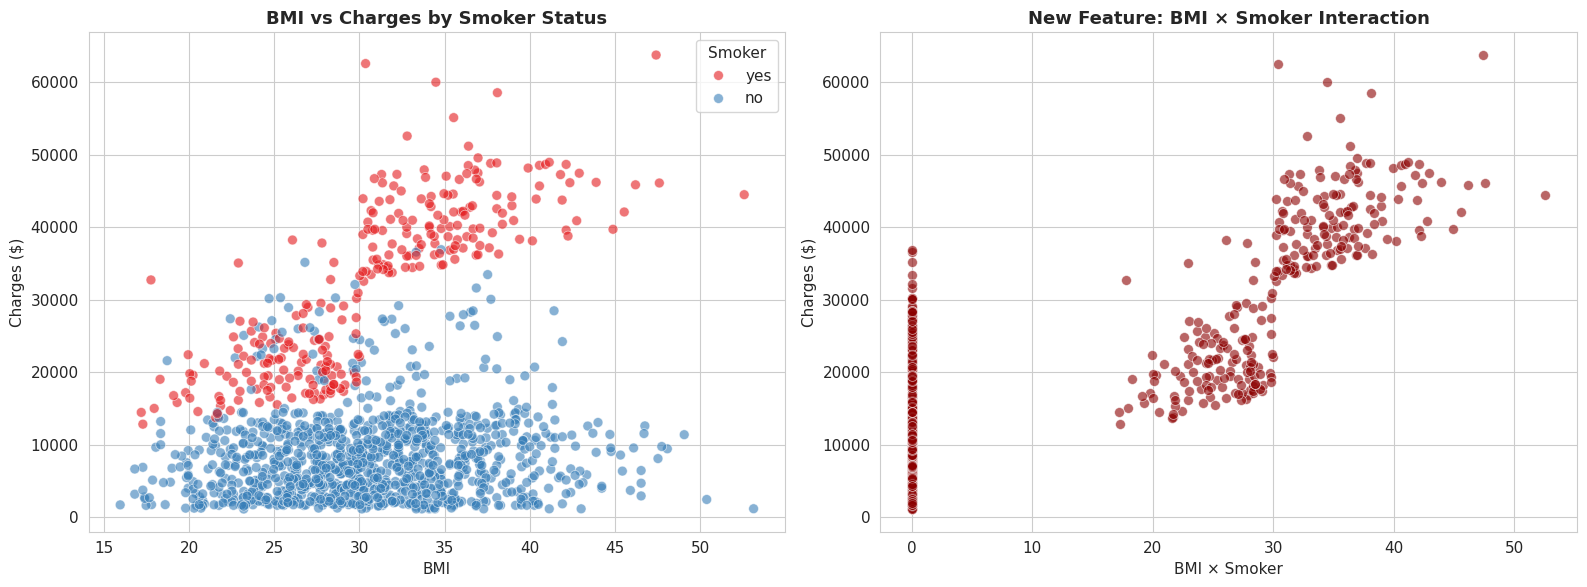


Correlación BMI con Charges:         0.198
Correlación Smoker con Charges:      0.787
Correlación BMI×Smoker con Charges:  0.845 <--Mejor que ambos por separado


In [96]:
# Crear feature de interacción
df['bmi_smoker'] = df['bmi'] * (df['smoker'] == 'yes').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot con hue
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', 
                alpha=0.6, s=50, ax=axes[0], palette='Set1')
axes[0].set_title('BMI vs Charges by Smoker Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges ($)')
axes[0].legend(title='Smoker')

# Nueva feature
sns.scatterplot(data=df, x='bmi_smoker', y='charges', 
                alpha=0.6, s=50, ax=axes[1], color='darkred')
axes[1].set_title('New Feature: BMI × Smoker Interaction', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI × Smoker')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

# Correlaciones
print(f"\nCorrelación BMI con Charges:         {df['bmi'].corr(df['charges']):.3f}")
print(f"Correlación Smoker con Charges:      {(df['smoker']=='yes').astype(int).corr(df['charges']):.3f}")
print(f"Correlación BMI×Smoker con Charges:  {df['bmi_smoker'].corr(df['charges']):.3f} <--Mejor que ambos por separado")

#### Ager x smoker

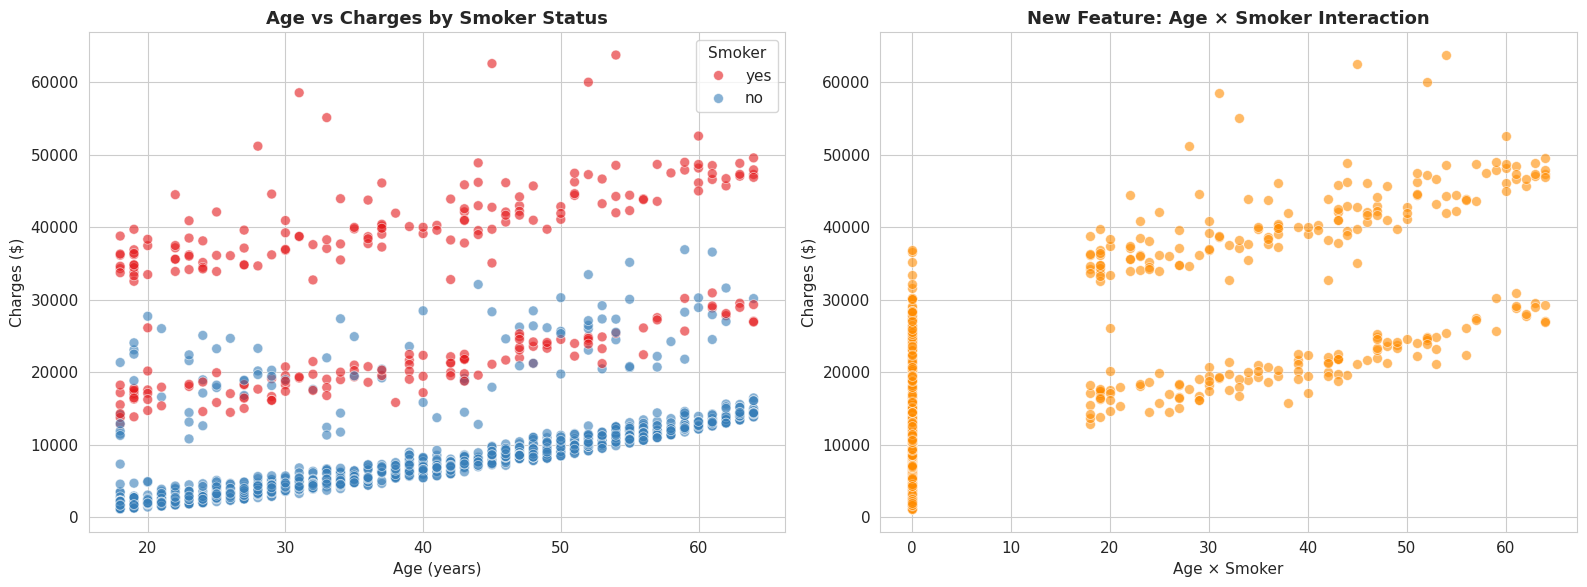


Correlación Age×Smoker con Charges:  0.789


In [99]:
# Crear feature de interacción
df['age_smoker'] = df['age'] * (df['smoker'] == 'yes').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot con hue
sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                alpha=0.6, s=50, ax=axes[0], palette='Set1')
axes[0].set_title('Age vs Charges by Smoker Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Charges ($)')
axes[0].legend(title='Smoker')

# Nueva feature
sns.scatterplot(data=df, x='age_smoker', y='charges',
                alpha=0.6, s=50, ax=axes[1], color='darkorange')
axes[1].set_title('New Feature: Age × Smoker Interaction', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age × Smoker')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

print(f"\nCorrelación Age×Smoker con Charges:  {df['age_smoker'].corr(df['charges']):.3f}")

### Transformacion de la target

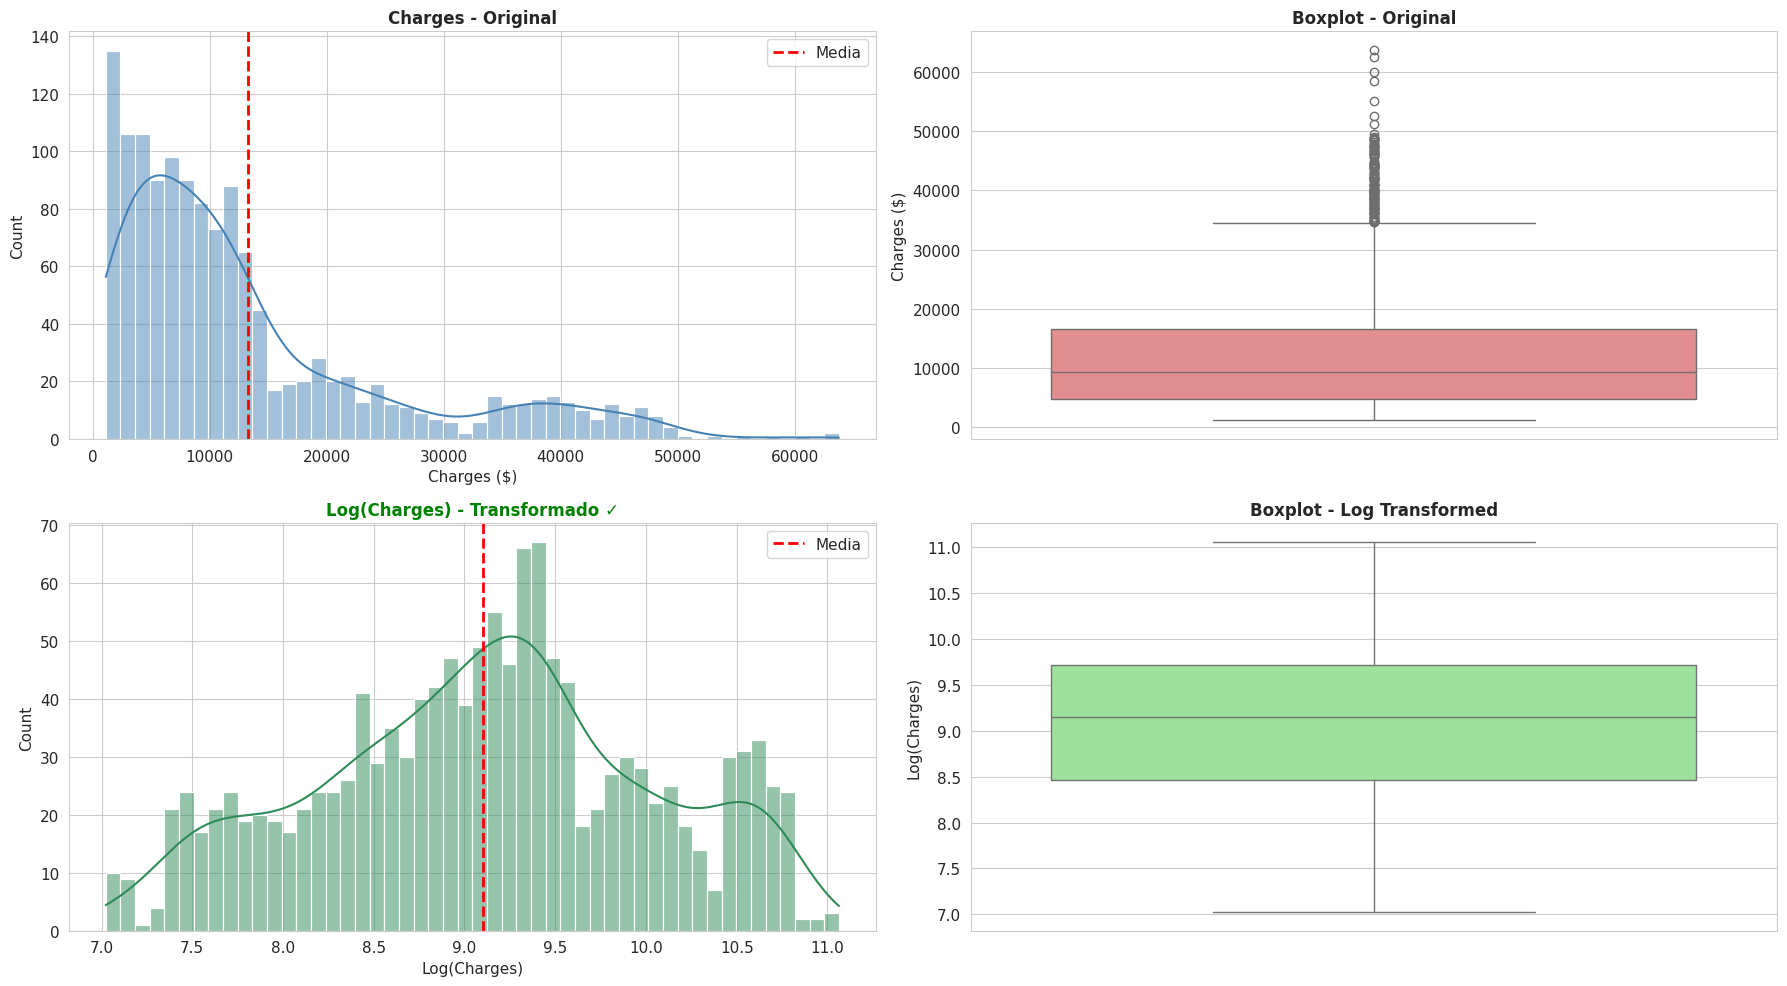

In [ ]:
# Transformación log
log_charges = np.log1p(df['charges'])  # log1p = log(1 + x)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# FILA 1: ORIGINAL
# Histograma original
sns.histplot(df['charges'], kde=True, bins=50, ax=axes[0, 0], color='steelblue')
axes[0, 0].axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0, 0].set_title('Charges - Original', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Charges ($)')
axes[0, 0].legend()


# Boxplot original
sns.boxplot(y=df['charges'], ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Boxplot - Original', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Charges ($)')

# FILA 2: LOG TRANSFORMADO
# Histograma log
sns.histplot(log_charges, kde=True, bins=50, ax=axes[1, 0], color='seagreen')
axes[1, 0].axvline(log_charges.mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[1, 0].set_title('Log(Charges) - Transformado ✓', fontsize=12, fontweight='bold', color='green')
axes[1, 0].set_xlabel('Log(Charges)')
axes[1, 0].legend()


# Boxplot log
sns.boxplot(y=log_charges, ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Boxplot - Log Transformed', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Log(Charges)')

plt.tight_layout()
plt.show()

In [113]:
# Comparación estadística
print('='*70)
print('COMPARACIÓN: ORIGINAL vs LOG TRANSFORMADO')
print('='*70)
print(f"\nSkewness:")
print(f"  Original:     {df['charges'].skew():7.3f}  (fuertemente asimétrica)")
print(f"  Log Transform: {log_charges.skew():7.3f}  (más simétrica) ✓")

print(f"\nKurtosis:")
print(f"  Original:     {df['charges'].kurtosis():7.3f}  (colas pesadas)")
print(f"  Log Transform: {log_charges.kurtosis():7.3f}  (más normal) ✓")

print(f"\nCONCLUSIÓN: Usar log(charges) como target mejora distribución")
print(f"   - Reduce skewness de {df['charges'].skew():.2f} a {log_charges.skew():.2f}")
print(f"   - Estabiliza varianza y cumple mejor supuestos de regresión")

COMPARACIÓN: ORIGINAL vs LOG TRANSFORMADO

Skewness:
  Original:       1.515  (fuertemente asimétrica)
  Log Transform:  -0.090  (más simétrica) ✓

Kurtosis:
  Original:       1.604  (colas pesadas)
  Log Transform:  -0.635  (más normal) ✓

CONCLUSIÓN: Usar log(charges) como target mejora distribución
   - Reduce skewness de 1.52 a -0.09
   - Estabiliza varianza y cumple mejor supuestos de regresión


### Terminos cuadraticos

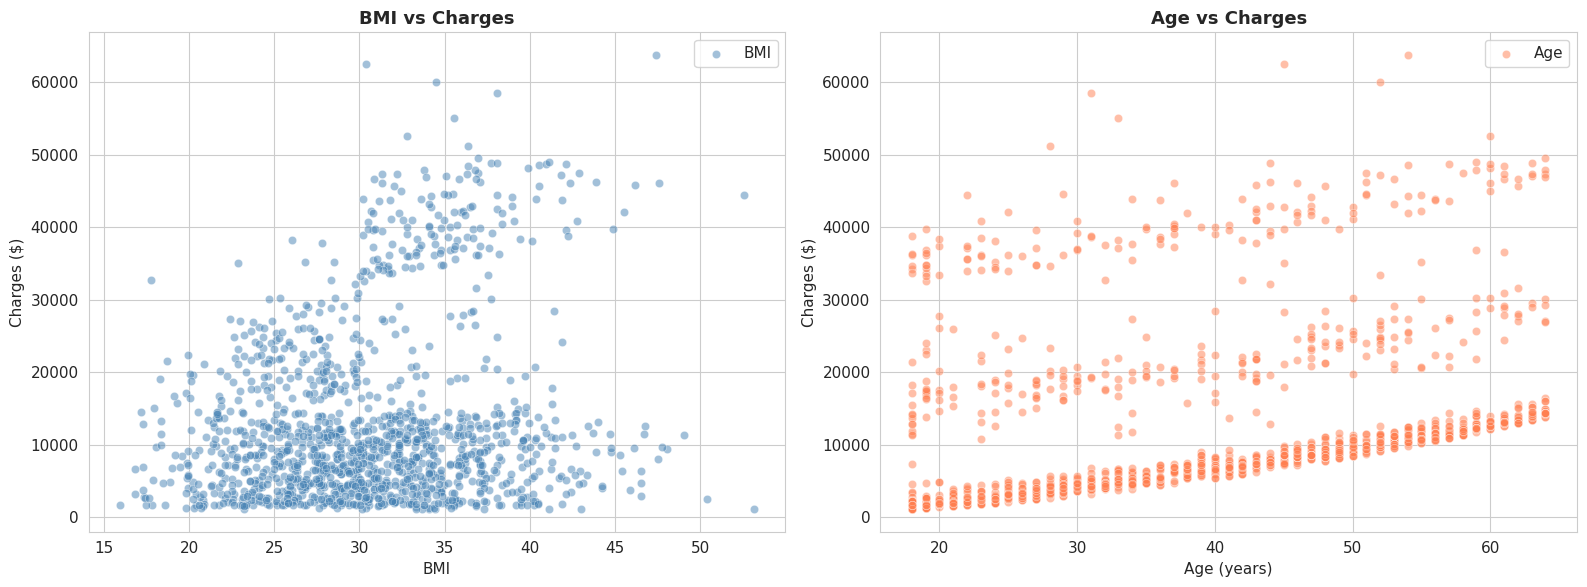


Correlaciones con Charges:
  BMI:         0.198
  BMI²:        0.193
  Age:         0.298
  Age²:        0.300


In [102]:
# Crear términos cuadráticos
df['bmi_squared'] = df['bmi'] ** 2
df['age_squared'] = df['age'] ** 2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BMI y BMI²
sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.5, ax=axes[0], color='steelblue', label='BMI')
axes[0].set_title('BMI vs Charges', fontsize=13, fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges ($)')

# Age y Age²
sns.scatterplot(data=df, x='age', y='charges', alpha=0.5, ax=axes[1], color='coral', label='Age')
axes[1].set_title('Age vs Charges', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

# Correlaciones
print(f"\nCorrelaciones con Charges:")
print(f"  BMI:         {df['bmi'].corr(df['charges']):.3f}")
print(f"  BMI²:        {df['bmi_squared'].corr(df['charges']):.3f}")
print(f"  Age:         {df['age'].corr(df['charges']):.3f}")
print(f"  Age²:        {df['age_squared'].corr(df['charges']):.3f}")

### Variables binarias

In [103]:
# Crear variables binarias
df['bmi_obese'] = (df['bmi'] > 30).astype(int)
df['age_senior'] = (df['age'] > 50).astype(int)

print('='*70)
print('VARIABLES BINARIAS CREADAS')
print('='*70)
print(f"\nBMI Obese (BMI > 30):")
print(f"  No Obesos:  {(df['bmi_obese']==0).sum()} ({(df['bmi_obese']==0).mean()*100:.1f}%)")
print(f"  Obesos:     {(df['bmi_obese']==1).sum()} ({(df['bmi_obese']==1).mean()*100:.1f}%)")

print(f"\nAge Senior (Age > 50):")
print(f"  No Senior:  {(df['age_senior']==0).sum()} ({(df['age_senior']==0).mean()*100:.1f}%)")
print(f"  Senior:     {(df['age_senior']==1).sum()} ({(df['age_senior']==1).mean()*100:.1f}%)")

VARIABLES BINARIAS CREADAS

BMI Obese (BMI > 30):
  No Obesos:  633 (47.3%)
  Obesos:     704 (52.7%)

Age Senior (Age > 50):
  No Senior:  981 (73.4%)
  Senior:     356 (26.6%)


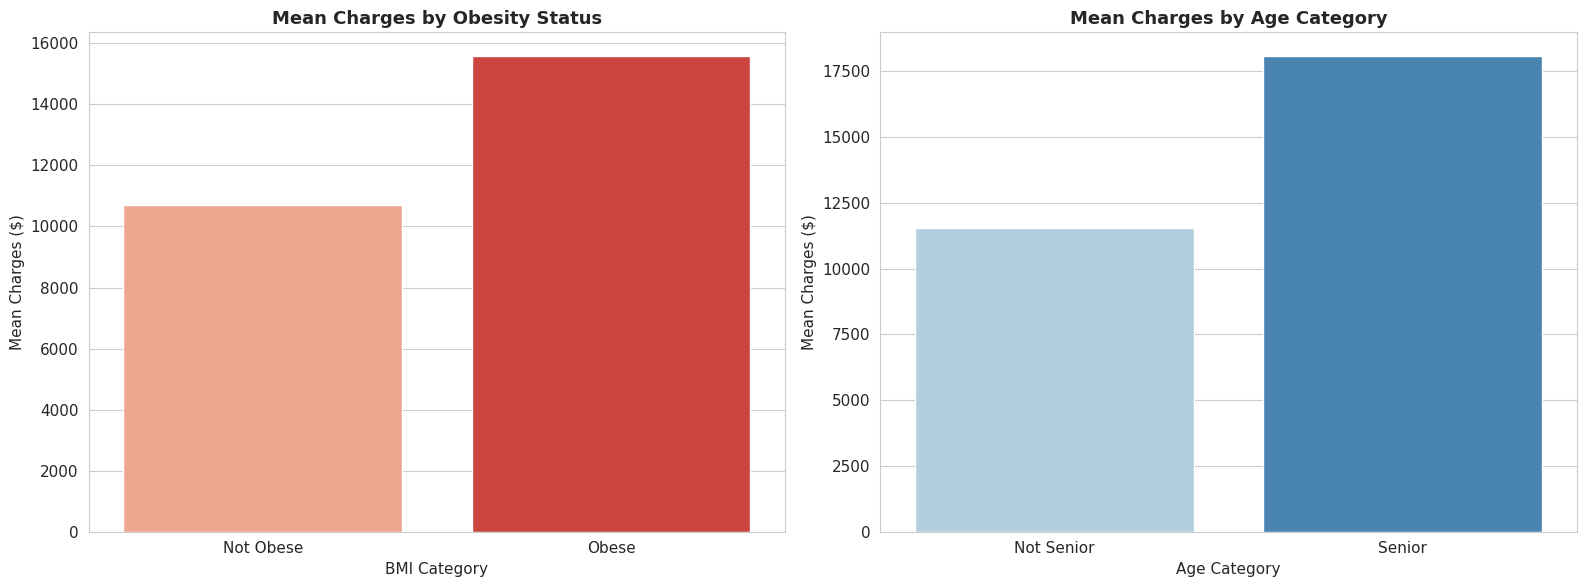

In [104]:
# Visualización de variables binarias
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BMI Obese
obesity_data = df.groupby('bmi_obese')['charges'].agg(['mean', 'median', 'std']).reset_index()
obesity_data['bmi_obese'] = obesity_data['bmi_obese'].map({0: 'Not Obese', 1: 'Obese'})
sns.barplot(data=obesity_data, x='bmi_obese', y='mean', ax=axes[0], palette='Reds')
axes[0].set_title('Mean Charges by Obesity Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Mean Charges ($)')

# Age Senior
age_data = df.groupby('age_senior')['charges'].agg(['mean', 'median', 'std']).reset_index()
age_data['age_senior'] = age_data['age_senior'].map({0: 'Not Senior', 1: 'Senior'})
sns.barplot(data=age_data, x='age_senior', y='mean', ax=axes[1], palette='Blues')
axes[1].set_title('Mean Charges by Age Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Category')
axes[1].set_ylabel('Mean Charges ($)')

plt.tight_layout()
plt.show()

### Matriz de correlacion nueva con variables transformadas e interacciones

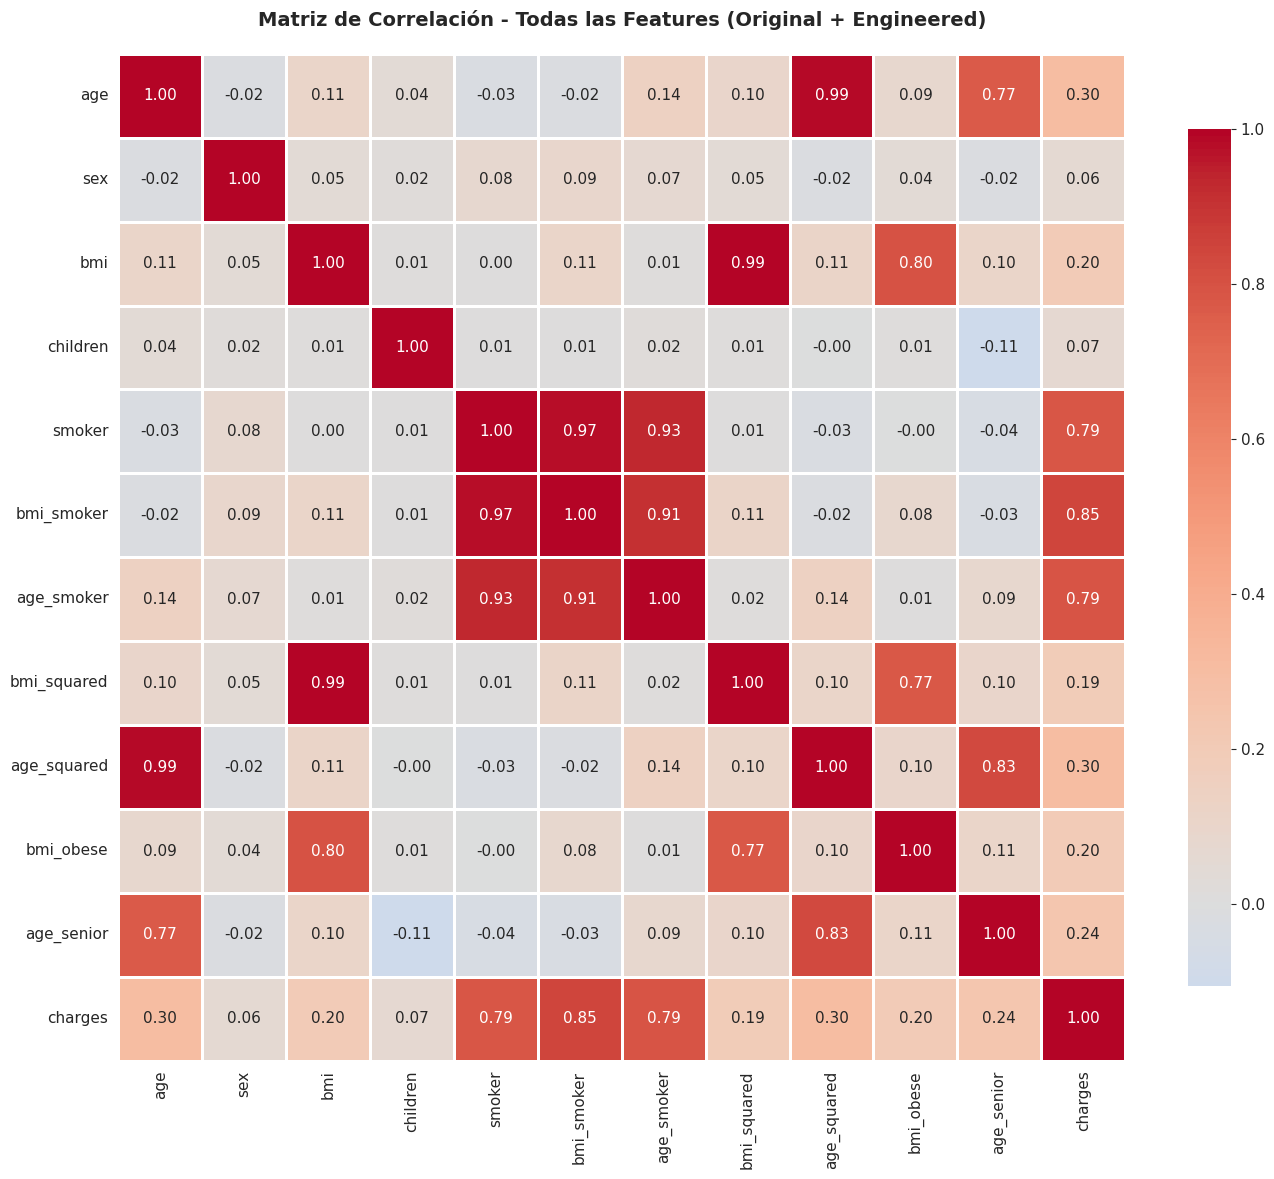

In [106]:
# Codificar categóricas
df_full_encoded = df.copy()
df_full_encoded['sex'] = (df_full_encoded['sex'] == 'male').astype(int)
df_full_encoded['smoker'] = (df_full_encoded['smoker'] == 'yes').astype(int)
df_full_encoded['region'] = df_full_encoded['region'].astype('category').cat.codes

# Features relevantes
features_for_corr = [
    'age', 'sex', 'bmi', 'children', 'smoker',
    'bmi_smoker', 'age_smoker', 'bmi_squared', 'age_squared',
    'bmi_obese', 'age_senior', 'charges'
]

corr_matrix_full = df_full_encoded[features_for_corr].corr()

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix_full, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0, 
            square=True, 
            linewidths=1,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación - Todas las Features (Original + Engineered)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [110]:
# Ranking de correlaciones con target
print('='*70)
print('RANKING DE CORRELACIONES CON CHARGES')
print('='*70)
target_corrs_full = corr_matrix_full['charges'].drop('charges').sort_values(ascending=False)
for i, (feature, corr) in enumerate(target_corrs_full.items(), 1):
    marker = '<-- > 0.5' if corr > 0.5 else ''
    print(f"  {i:2d}. {feature:20s}: {corr:6.3f} {marker}")

RANKING DE CORRELACIONES CON CHARGES
   1. bmi_smoker          :  0.845 <-- > 0.5
   2. age_smoker          :  0.789 <-- > 0.5
   3. smoker              :  0.787 <-- > 0.5
   4. age_squared         :  0.300 
   5. age                 :  0.298 
   6. age_senior          :  0.239 
   7. bmi_obese           :  0.201 
   8. bmi                 :  0.198 
   9. bmi_squared         :  0.193 
  10. children            :  0.067 
  11. sex                 :  0.058 


### Outliers

In [111]:

def detect_outliers_iqr(data, column):
    """Detectar outliers usando método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    print(f"\n{column}:")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")

    return outliers

for col in ['age', 'bmi', 'charges']:
    outliers = detect_outliers_iqr(df, col)
    
print("\nNOTA: Los outliers en 'charges' son esperables en datos de seguros")
print("   (casos médicos graves, enfermedades crónicas, etc.)")


age:
  Lower bound: -9.00
  Upper bound: 87.00
  Outliers detectados: 0 (0.0%)

bmi:
  Lower bound: 13.67
  Upper bound: 47.32
  Outliers detectados: 9 (0.7%)

charges:
  Lower bound: -13120.72
  Upper bound: 34524.78
  Outliers detectados: 139 (10.4%)

NOTA: Los outliers en 'charges' son esperables en datos de seguros
   (casos médicos graves, enfermedades crónicas, etc.)


## Conclusiones

##### Variable Target: Charges:
- Distribucion asimetrica
- Rango amplio: 1121 a 63770
- Media > Mediana
- Distribución asimétrica (skewness = 1.52)
- Alta varianza (std = $12,110.36)

--> **Tomando el log(charges)**
- Reduce skewness a -0.09
- Estabiliza varianza
- Mejora performance del modelo

##### Features mas correlacionada con charges:
- smoker:      0.787  (CRÍTICO - factor más importante)
- bmi_smoker:  0.845  (Interacción creada)
- age:         0.298
- age_smoker:  0.789  (Interacción creada)
- bmi:         0.198

##### FEATURES A INCLUIR EN EL MODELO:
- Originales:    age, sex, bmi, children, smoker, region
- Interacciones: bmi_smoker, age_smoker
- Cuadráticas:   bmi_squared, age_squared
- Binarias:      bmi_obese, age_senior

##### Observaciones clave:
- Los fumadores tienen costos ~3.8x mayores que no fumadores
- Interacción smoker × BMI es CRÍTICA para predicción
- Age tiene efecto lineal moderado pero consistente
- Region y children tienen impacto menor

##### Calidad de los datos:
- No hay valores nulos en el dataset
- No hay lineas duplicadas
- La variable target presenta algunos valores que podrian ser considerados outliers, pero en el rubro de seguros no necesariamente.

##### Insights del EDA:
- Algoritmo: XGBoost (captura no-linealidades)
- Target: log(charges) con inversión en predicción
- Features: Incluir todas las engineered creadas aquí
- Validación: K-fold CV para evitar overfitting